In [1]:
# Author: Arthur Prigent
# Email: arhtur.prigent@univ-brest.fr

In [35]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy
import matplotlib
import scipy
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib.colors as mcolors

from datetime import datetime, timedelta
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import glob
import matplotlib.pyplot as plt
import cmocean
import netCDF4
import matplotlib.path as mpath
import cartopy.feature as cfeature
import ArcTools as Atools


# Load ETOPO bathy

In [36]:


etopo = xr.open_dataset('/data0/data/REFERENCE_DATA/BATHYMETRY/DATA/ETOPO2v2c_f4.nc')
lon_bat = etopo.x.data
lat_bat = etopo.y.data
topo = etopo.z.data


lon_bat_low = lon_bat[::2]
lat_bat_low = lat_bat[::2]
topo_low = topo[::2,::2]
del etopo,topo,lon_bat,lat_bat

In [37]:
ds_topo = xr.Dataset(
    data_vars={
        "topo": (("lat", "lon"), topo_low)
    },
    coords={
        "lon": ("lon", lon_bat_low),
        "lat": ("lat", lat_bat_low)
    }
)


# Define the different masks

In [38]:
# Convert longitude to 0-360
ds_topo_360 = ds_topo.copy()
ds_topo_360 = ds_topo_360.assign_coords(lon=((ds_topo_360.lon + 360) % 360))



ds_topo_AMERASIAN = ds_topo_360.where(
    
    (ds_topo_360.topo < -1000) &(ds_topo_360.lat>66)&
    ((ds_topo_360.lon <= 300) & (ds_topo_360.lon >= 150))
    |
    (ds_topo_360.topo > -1000) &(ds_topo_360.lat>84.1)&
    ((ds_topo_360.lon <= 300) & (ds_topo_360.lon >= 270))
    |
    (ds_topo_360.topo > -1000) &(ds_topo_360.lat>84.2)&
    ((ds_topo_360.lon <= 160) & (ds_topo_360.lon >= 150))

)


# Make a copy so you don't overwrite the original
ds_topo_masked = ds_topo_AMERASIAN.copy()

# Define the mask
mask = (
    (ds_topo_masked.lon >= 270) & (ds_topo_masked.lon <= 320) &
    (ds_topo_masked.lat >= 66) & (ds_topo_masked.lat <= 80)
)

# Apply mask: set topo to NaN in that region
ds_topo_AMERASIAN['topo'] = ds_topo_AMERASIAN['topo'].where(~mask)



ds_topo_AMERASIAN_shelf = ds_topo_360.where(
    (ds_topo_360.topo >= -1000)&(ds_topo_360.topo <0) &(ds_topo_360.lat>66)&
    ((ds_topo_360.lon <= 240) & (ds_topo_360.lon >= 180)))



ds_topo_SIBERIAN_shelf = ds_topo_360.where(
    (ds_topo_360.topo >= -1000)&(ds_topo_360.topo <0) &(ds_topo_360.lat>66)&(ds_topo_360.lat<=82)&
    ((ds_topo_360.lon <= 180) & (ds_topo_360.lon >= 95)))


# Make a copy so you don't overwrite the original
ds_topo_masked = ds_topo_SIBERIAN_shelf.copy()

# Define the mask
mask = (
    (ds_topo_masked.lon >= 140) & (ds_topo_masked.lon <= 150) &
    (ds_topo_masked.lat >= 80) & (ds_topo_masked.lat <= 85)
)

# Apply mask: set topo to NaN in that region
ds_topo_SIBERIAN_shelf['topo'] = ds_topo_SIBERIAN_shelf['topo'].where(~mask)




mask_EURASIAN = ds_topo_360.where(
    (ds_topo_360.topo < -1000) & (ds_topo_360.lat > 75)&(
        ((ds_topo_360.lon >= 30) &
        (ds_topo_360.lon <= 150)
        )

        |
        (   (ds_topo_360.lat > 80)&
            (ds_topo_360.lon >= 300) &
            (ds_topo_360.lon <= 360)
        )
        |
        (   (ds_topo_360.lat > 80)&
            (ds_topo_360.lon >= 0) &
            (ds_topo_360.lon < 30)
        )
    )
    |
    (ds_topo_360.topo > -1000) &(ds_topo_360.lat>84.2)&
    ((ds_topo_360.lon <= 310) & (ds_topo_360.lon >= 300))
    |
    (ds_topo_360.topo > -1000) &(ds_topo_360.lat>84.2)&
    ((ds_topo_360.lon <= 150) & (ds_topo_360.lon >= 120))
    
    |
    (ds_topo_360.topo > -1000) &(ds_topo_360.lat>84.2)&
    ((ds_topo_360.lon <= 350) & (ds_topo_360.lon >= 325))
    |
    (ds_topo_masked.lon >= 140) & (ds_topo_masked.lon <= 150) &
    (ds_topo_masked.lat >= 80) & (ds_topo_masked.lat <= 85)
    
)

# )


ds_topo_NORDIC = ds_topo_360.where(
    (ds_topo_360.topo < -1000)&(ds_topo_360.lat>66)&(ds_topo_360.lat<=80)&
    (((ds_topo_360.lon >= 330) &
      (ds_topo_360.lon < 360))
     |
     ((ds_topo_360.lon >= 0) &
      (ds_topo_360.lon < 30)))
     |
    (ds_topo_360.topo > -1000) &(ds_topo_360.lat>69)&(ds_topo_360.lat<73)&
    ((ds_topo_360.lon <= 360) & (ds_topo_360.lon >= 343.5))
    

)

ds_topo_BARENTS = ds_topo_360.where(
    (ds_topo_360.topo >= -1000)&(ds_topo_360.topo < 0)&(ds_topo_360.lat>66)&
    (((ds_topo_360.lon >= 2) & (ds_topo_360.lon < 60))))

ds_topo_KARA = ds_topo_360.where(
    (ds_topo_360.topo >= -1000)&(ds_topo_360.topo < 0)&(ds_topo_360.lat>66)&
    (((ds_topo_360.lon >= 60) & (ds_topo_360.lon < 95))))


ds_topo_GREENSHELF = ds_topo_360.where(
    (ds_topo_360.topo >= -1000)&(ds_topo_360.topo < 0)&(ds_topo_360.lat>66)&(ds_topo_360.lat<84.1)&
    (((ds_topo_360.lon >= 330) & (ds_topo_360.lon < 360))))


# Make a copy so you don't overwrite the original
ds_topo_masked = ds_topo_GREENSHELF.copy()

# Define the mask
mask = (
    (ds_topo_360.topo > -1000) &(ds_topo_360.lat>68)&(ds_topo_360.lat<73)&
    ((ds_topo_360.lon <= 360) & (ds_topo_360.lon >= 343))
)

# Apply mask: set topo to NaN in that region
ds_topo_GREENSHELF['topo'] = ds_topo_GREENSHELF['topo'].where(~mask)



ds_topo_BAFFIN = ds_topo_360.where(
    (ds_topo_360.topo < 0)&(ds_topo_360.lat>66)&(ds_topo_360.lat<=78)&
    (((ds_topo_360.lon >= 288) & (ds_topo_360.lon < 320))))


ds_topo_CANADA = ds_topo_360.where(
    (ds_topo_360.topo < 0)&(ds_topo_360.topo >= -1000)&(ds_topo_360.lat>66)&(ds_topo_360.lat<84)&
    (((ds_topo_360.lon < 288) & (ds_topo_360.lon >= 240)))
    |
    (ds_topo_360.topo < 0)&(ds_topo_360.topo > -1000) &(ds_topo_360.lat>78)&(ds_topo_360.lat<84.46)&
    ((ds_topo_360.lon <= 330) & (ds_topo_360.lon >= 288)))


In [39]:
ds_regions = xr.Dataset(
    {
        "AMERASIAN": ds_topo_AMERASIAN.topo,
        "AMERASIAN_SHELF": ds_topo_AMERASIAN_shelf.topo,
        "SIBERIAN_SHELF": ds_topo_SIBERIAN_shelf.topo,
        "EURASIAN": mask_EURASIAN.topo,
        "NORDIC": ds_topo_NORDIC.topo,
        "BARENTS": ds_topo_BARENTS.topo,
        "KARA": ds_topo_KARA.topo,
        "GREEN_SHELF": ds_topo_GREENSHELF.topo,
        "BAFFIN": ds_topo_BAFFIN.topo,
        "CANADA": ds_topo_CANADA.topo,
    }
)
ds_masks = ds_regions.notnull().astype(int)
ds_masks = ds_masks.assign_coords(
    lon=((ds_masks.lon + 360) % 360)
).sortby("lon")

In [40]:
basins_topo = {
    "AMERASIAN": ds_topo_AMERASIAN.topo,
    "AMERASIAN_SHELF": ds_topo_AMERASIAN_shelf.topo,
    "SIBERIAN_SHELF": ds_topo_SIBERIAN_shelf.topo,
    "EURASIAN": mask_EURASIAN.topo,
    "NORDIC": ds_topo_NORDIC.topo,
    "BARENTS": ds_topo_BARENTS.topo,
    "KARA": ds_topo_KARA.topo,
    "GREEN_SHELF": ds_topo_GREENSHELF.topo,
    "BAFFIN": ds_topo_BAFFIN.topo,
    "CANADA": ds_topo_CANADA.topo,
}

ds_stats = xr.Dataset(
    {
        "avg_topo": xr.DataArray(
            [da.mean() for da in basins_topo.values()],
            coords={"basin": list(basins_topo.keys())},
            dims="basin",
        ),
        "min_topo": xr.DataArray(
            [da.min() for da in basins_topo.values()],
            coords={"basin": list(basins_topo.keys())},
            dims="basin",
        ),
    }
)



In [41]:
import pandas as pd
import numpy as np

boxes = pd.read_csv('/home/aprigent/Documents/Projects/Analysis_obs/Arctic_design_10m_150_test_new.csv')



xc150 = np.array(([boxes["Longitude 1"].values,boxes["Longitude 2"].values,
                   boxes["Longitude 2"].values,boxes["Longitude 1"].values,boxes["Longitude 1"].values])).T
yc150 = np.array(([boxes["Latitude 1"].values,boxes["Latitude 1"].values,
                   boxes["Latitude 2"].values,boxes["Latitude 2"].values,boxes["Latitude 1"].values])).T
box_id = np.array(boxes["Box ID"].values)

# Plot masks to check

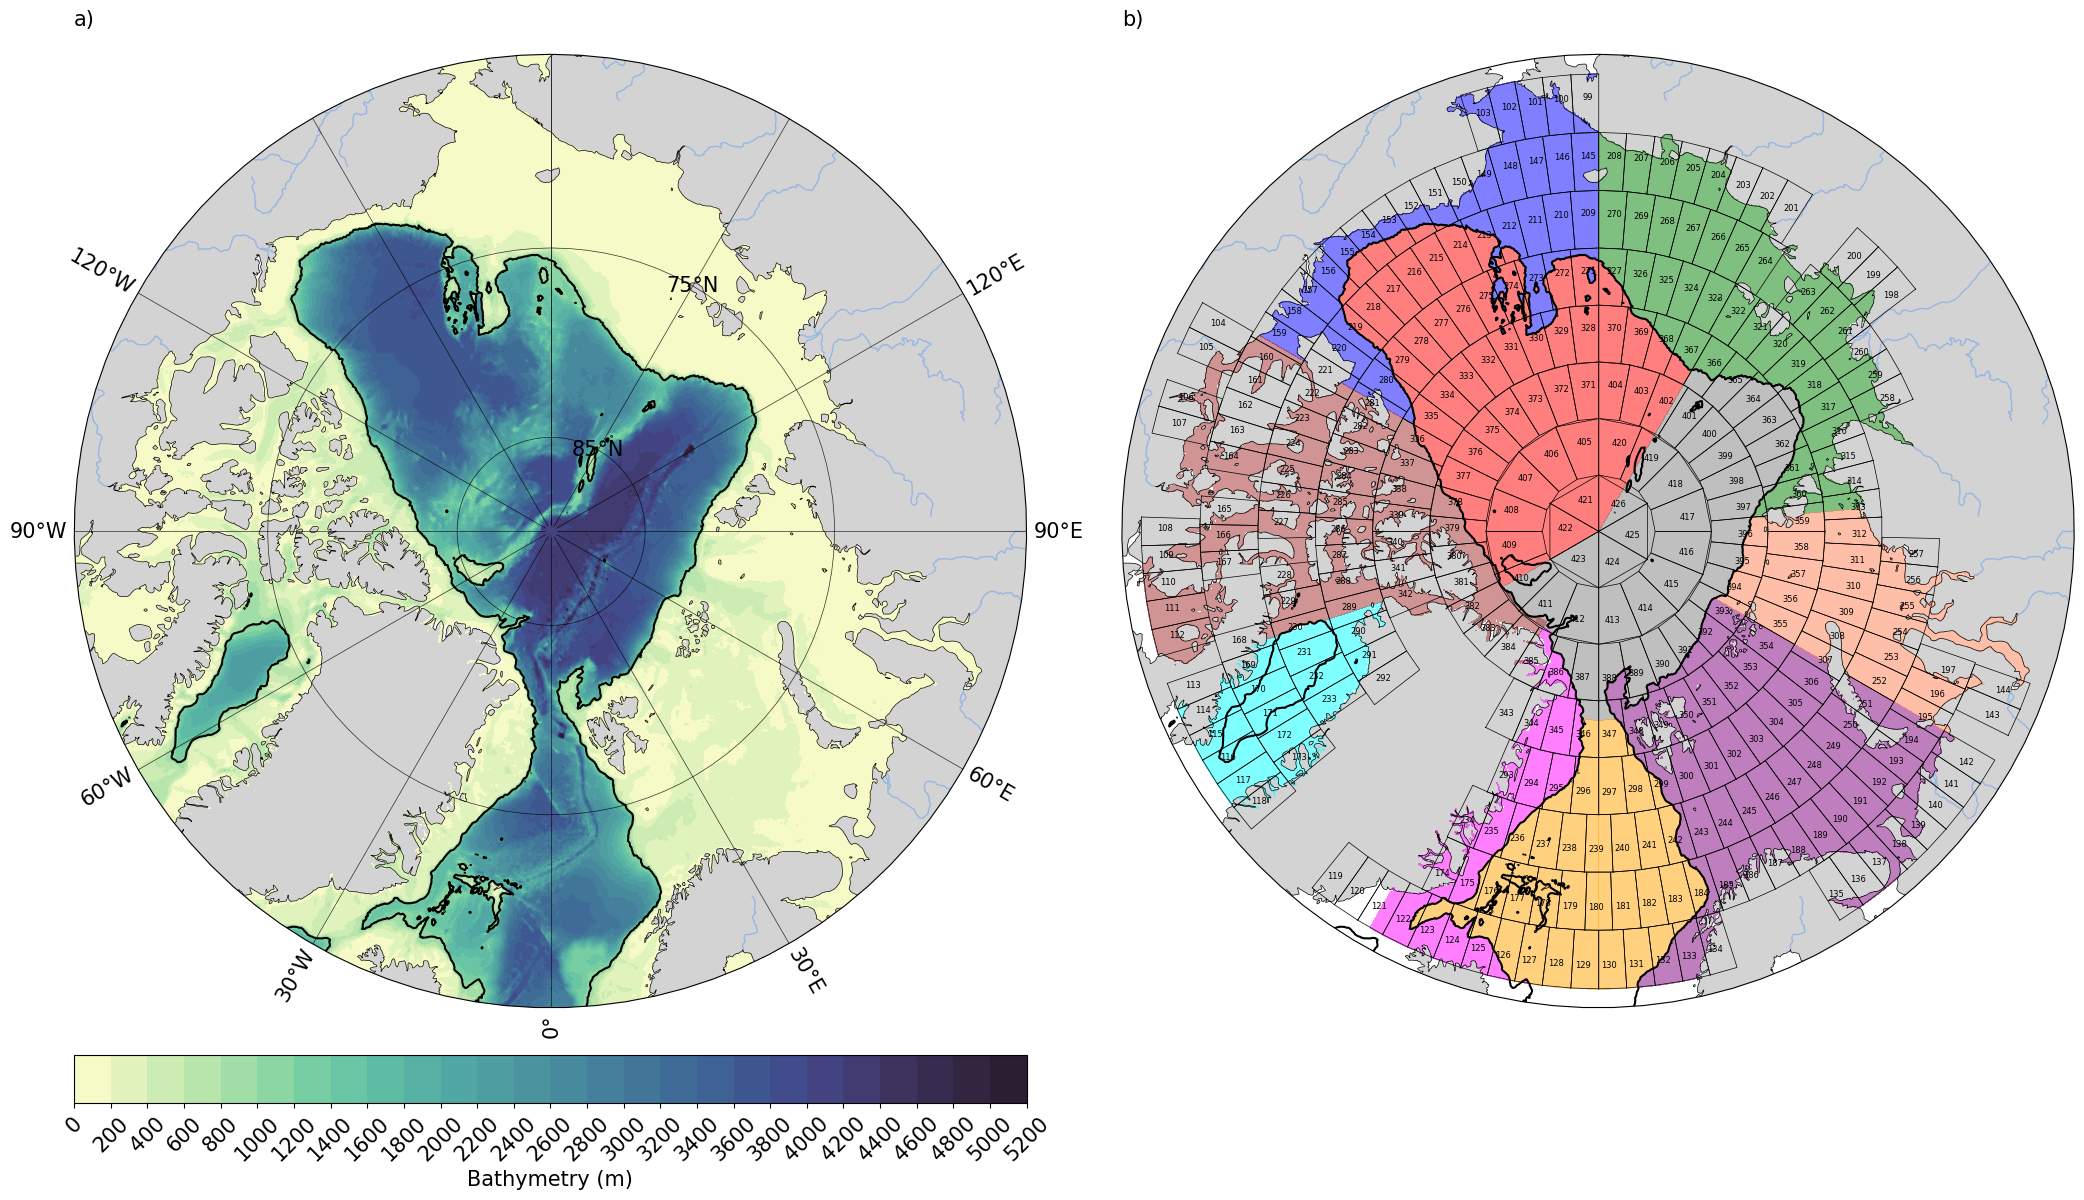

In [42]:
f,ax = plt.subplots(1,2,figsize=[20,10],subplot_kw={'projection': ccrs.NorthPolarStereo()})
ax=ax.ravel()
import string
ftz=15
levels=np.arange(0,5400,200)
plt.subplots_adjust(top=1, bottom=0, left=0, right=1, hspace=0
                    ,
                    wspace=0.1)
cax = inset_axes(ax[0],
                   width="100%",  # width = 5% of parent_bbox width
                   height="5%",  # height : 50%
                   loc='lower left',
                   bbox_to_anchor=(0, -0.1, 1, 1),
                   bbox_transform=ax[0].transAxes,
                   borderpad=0,
                   )
Atools.plot_arctic_ax_map_new(ax[0],gridlines=True)

p0=ax[0].contourf(ds_topo.lon,
               ds_topo.lat,
               -ds_topo.topo,levels=levels,cmap=cmocean.cm.deep,transform=ccrs.PlateCarree())
cbar = plt.colorbar(p0,cax,orientation='horizontal',ticks=levels)
cbar.ax.tick_params(labelsize=ftz,rotation=45)
cbar.set_label('Bathymetry (m)', size=ftz)


cs=ax[0].contour(ds_topo.lon,ds_topo.lat,(-1)*ds_topo.topo,[1000],cmap="Greys_r",transform=ccrs.PlateCarree())#,cmap='ocean')
Atools.plot_arctic_ax_map_new(ax[1],gridlines=False)

cs=ax[1].contour(ds_topo.lon,ds_topo.lat,(-1)*ds_topo.topo,[1000],cmap="Greys_r",transform=ccrs.PlateCarree())#,cmap='ocean')

ax[1].contourf(
    ds_masks.lon,
    ds_masks.lat,
    ds_masks.AMERASIAN,
    levels=[0.5,1.5],
    transform=ccrs.PlateCarree(),colors='red',alpha=0.5
)
ax[1].contourf(
    ds_masks.lon,
    ds_masks.lat,
    ds_masks.AMERASIAN_SHELF,
    levels=[0.5,1.5],
    transform=ccrs.PlateCarree(),colors='blue',alpha=0.5
)
ax[1].contourf(
    ds_masks.lon,
    ds_masks.lat,
    ds_masks.SIBERIAN_SHELF,
    levels=[0.5,1.5],
    transform=ccrs.PlateCarree(),colors='green',alpha=0.5
)
ax[1].contourf(
    ds_masks.lon,
    ds_masks.lat,
    ds_masks.EURASIAN,
    levels=[0.5,1.5],
    transform=ccrs.PlateCarree(),colors='grey',alpha=0.5
)
ax[1].contourf(
    ds_masks.lon,
    ds_masks.lat,
    ds_masks.NORDIC,
    levels=[0.5,1.5],
    transform=ccrs.PlateCarree(),colors='orange',alpha=0.5
)
ax[1].contourf(
    ds_masks.lon,
    ds_masks.lat,
    ds_masks.BARENTS,
    levels=[0.5,1.5],
    transform=ccrs.PlateCarree(),colors='purple',alpha=0.5
)

ax[1].contourf(
    ds_masks.lon,
    ds_masks.lat,
    ds_masks.KARA,
    levels=[0.5,1.5],
    transform=ccrs.PlateCarree(),colors='coral',alpha=0.5
)

ax[1].contourf(
    ds_masks.lon,
    ds_masks.lat,
    ds_masks.GREEN_SHELF,
    levels=[0.5,1.5],
    transform=ccrs.PlateCarree(),colors='magenta',alpha=0.5
)

ax[1].contourf(
    ds_masks.lon,
    ds_masks.lat,
    ds_masks.BAFFIN,
    levels=[0.5,1.5],
    transform=ccrs.PlateCarree(),colors='cyan',alpha=0.5
)

ax[1].contourf(
    ds_masks.lon,
    ds_masks.lat,
    ds_masks.CANADA,
    levels=[0.5,1.5],
    transform=ccrs.PlateCarree(),colors='brown',alpha=0.5

)

for i in range(len(xc150)):
    if np.all(yc150[i] >= 65):
        ax[1].plot(xc150[i],yc150[i],'k',linewidth=.5, transform=ccrs.PlateCarree())
        ax[1].text(np.mean(xc150[i]),np.mean(yc150[i]),box_id[i], fontsize=6,
                   color='black',transform=ccrs.PlateCarree(),va='center',ha='center')

for i in range(ax.shape[0]):
    ax[i].text(0,
     1.03,  str(string.ascii_lowercase[i])+')',transform=ax[i].transAxes,size=ftz)

    

plt.savefig('/home/aprigent/Documents/Projects/Analysis_obs/figures/fig_masks_topo.png',bbox_inches='tight',dpi=300)

# Save masks into netcdf

In [43]:
ds_masks.to_netcdf('/data0/user/aprigent/mask_regions.nc')

In [44]:
ds_stats.to_netcdf('/data0/user/aprigent/stats_mask_regions.nc')